# Import libraries and read dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Master/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
dataset.shape

(7043, 21)

In [ ]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Distinguish between categorical and numerical columns
categorical_col = []
numerical_col = []
for column in dataset.columns:

    if dataset[column].dtypes != "float64" and dataset[column].dtypes != "int64":
        categorical_col.append(column)
    else:
        numerical_col.append(column)

In [ ]:
numerical_col

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [ ]:
categorical_col

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

# Data Exploration

In [ ]:
# Transform categorical values to numerical
le = LabelEncoder()

label_mappings = {}

for col in categorical_col:
    dataset[col] = le.fit_transform(dataset[col])
    label_mappings[col] = le.classes_ # classes holds the label for each class

In [ ]:
label_mappings

{'customerID': array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
        '9993-LHIEB', '9995-HOTOH'], dtype=object),
 'gender': array(['Female', 'Male'], dtype=object),
 'Partner': array(['No', 'Yes'], dtype=object),
 'Dependents': array(['No', 'Yes'], dtype=object),
 'PhoneService': array(['No', 'Yes'], dtype=object),
 'MultipleLines': array(['No', 'No phone service', 'Yes'], dtype=object),
 'InternetService': array(['DSL', 'Fiber optic', 'No'], dtype=object),
 'OnlineSecurity': array(['No', 'No internet service', 'Yes'], dtype=object),
 'OnlineBackup': array(['No', 'No internet service', 'Yes'], dtype=object),
 'DeviceProtection': array(['No', 'No internet service', 'Yes'], dtype=object),
 'TechSupport': array(['No', 'No internet service', 'Yes'], dtype=object),
 'StreamingTV': array(['No', 'No internet service', 'Yes'], dtype=object),
 'StreamingMovies': array(['No', 'No internet service', 'Yes'], dtype=object),
 'Contract': array(['Month-to-month', 'One year', 'Tw

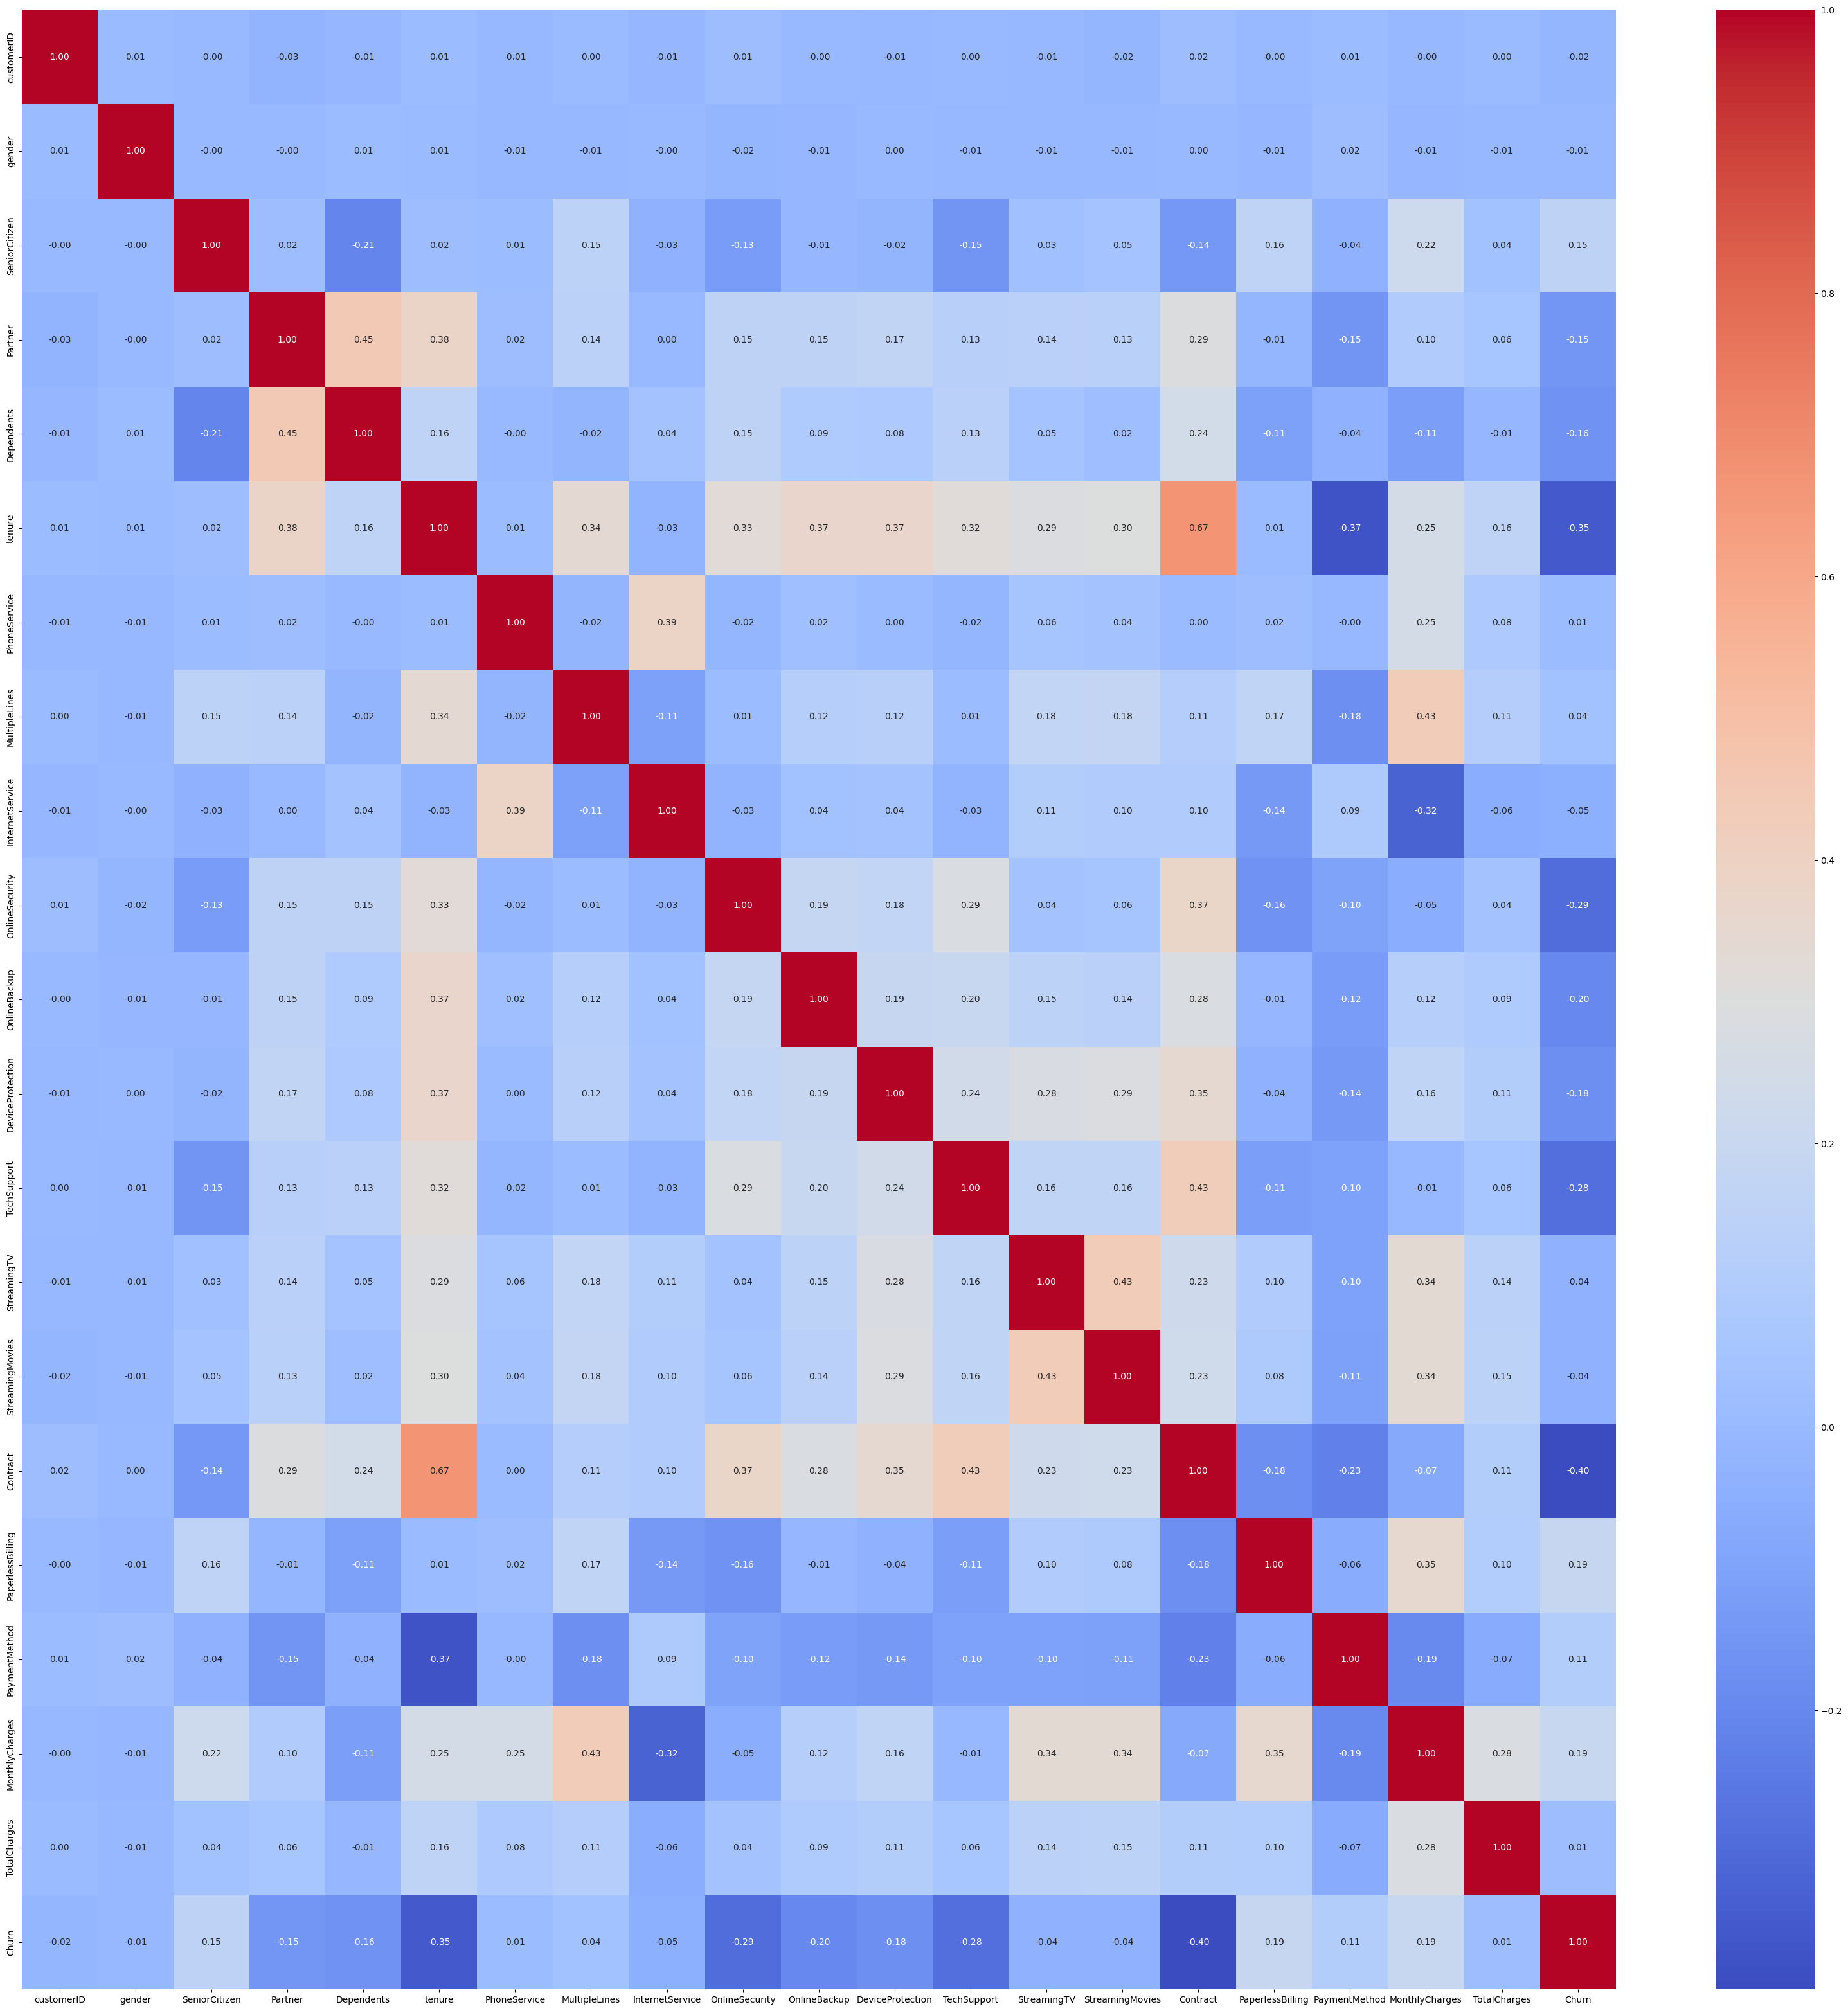

In [ ]:
# Plot all values on heatmap in order to see the correlation
plt.figure(figsize = (40,40))
sns.heatmap(dataset.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [ ]:
# Based on heatmap and correlation between columns, decide which columns to use as features
df = dataset[['SeniorCitizen', 'tenure', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'Contract', 'MonthlyCharges', 'Churn']]

In [ ]:
# Tabular representations of correlation between features and label
corr_matrix = df.corr()
top_correlations = corr_matrix['Churn'].abs().nlargest(11)[1:]
top_correlations

,Churn
Contract,0.396713
tenure,0.352229
OnlineSecurity,0.289309
TechSupport,0.282492
OnlineBackup,0.195525
MonthlyCharges,0.193356
SeniorCitizen,0.150889
MultipleLines,0.038037


In [ ]:
# Dataset with features and label
df.head()

,SeniorCitizen,tenure,MultipleLines,OnlineSecurity,OnlineBackup,TechSupport,Contract,MonthlyCharges,Churn
0,0,1,1,0,2,0,0,29.85,0
1,0,34,0,2,0,0,1,56.95,0
2,0,2,0,2,2,0,0,53.85,1
3,0,45,1,2,0,2,1,42.30,0
4,0,2,0,0,0,0,0,70.70,1


In [ ]:
df.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MultipleLines,0
OnlineSecurity,0
OnlineBackup,0
TechSupport,0
Contract,0
MonthlyCharges,0
Churn,0


In [ ]:
# Describe MonthlyCharges and tenure since those are the numerical columns we have
df["MonthlyCharges"].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [ ]:
# Create a copy of df and use it for plotting
df_plot = df.copy()
df_plot['Churn'] = df_plot['Churn'].map({0: 'No Churn', 1: 'Churn'})

df_long = df_plot.groupby('Churn').size().reset_index(name='count')

fig = px.bar(
    df_long,
    x='Churn',
    y='count',
    color='Churn',
    title='Churn Distribution',
    color_discrete_map={'No Churn':'lightblue','Churn':'salmon'}
)
fig.show()

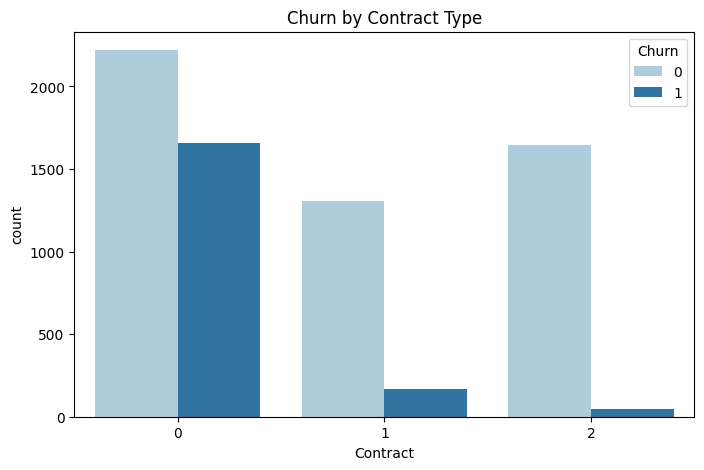

In [ ]:
# Visualization of how contract types impact churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Paired')
plt.title('Churn by Contract Type')
plt.show()

In [ ]:
# Visualization representing churn probability compared to tenure period
churn_by_tenure = (df.groupby('tenure')['Churn'].mean().reset_index())
# group df by tenure, for each tenure value calculate average of Churn

fig = px.line(
    churn_by_tenure,
    x='tenure',
    y='Churn',
    title='Churn Probability vs Tenure',
    labels={
        'tenure': 'Tenure (months)',
        'Churn': 'Churn Probability'
    }
)

fig.show()


# Separate features and label

In [ ]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [ ]:
X.shape

(7043, 8)

In [ ]:
y.shape

(7043,)

# Split into train and test set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state=40)

In [ ]:
for a in (X_train, X_test, y_train, y_test):
    print (a.shape)

(5634, 8)
(1409, 8)
(5634,)
(1409,)


# Feature scaling

In [ ]:
# Fit on training set only to prevent data leakage
scaler = StandardScaler() # creates a mean of 0, and std of 1

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression (using non-scaled features)

In [ ]:
# Create Logistic Regression model for unscaled features
logreg = LogisticRegression(max_iter = 200)

logreg.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
y_pred = logreg.predict(X_test)

In [ ]:
accuracy_score(y_pred, y_test)

0.7892122072391767

# Logistic regression (using scaled features)

In [ ]:
# Create Logistic Regression model for scaled features
logregsc = LogisticRegression(max_iter = 200)

logregsc.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=200)

In [ ]:
y_predsc = logregsc.predict(X_test_scaled)

In [ ]:
accuracy_score(y_predsc, y_test)

0.7899219304471257

# Compare models

In [ ]:
print("Without scaling:\n", classification_report(y_test, y_pred))
print("With scaling:\n", classification_report(y_test, y_predsc))

Without scaling:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1034
           1       0.63      0.52      0.57       375

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

With scaling:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1034
           1       0.63      0.52      0.57       375

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



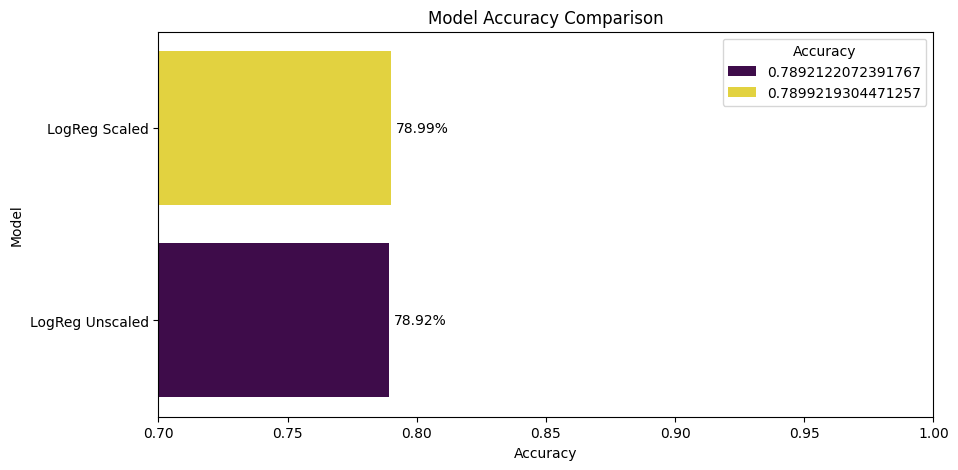

In [ ]:
# Compare and visualize the accuracy of scaled vs unscaled Logistic Regression models
model_scores = {
    'LogReg Unscaled': accuracy_score(y_test, y_pred),
    'LogReg Scaled': accuracy_score(y_test, y_predsc)
}

# create a dataframe containing model scores
results_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
barplot = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis',hue='Accuracy')

for index, value in enumerate(results_df['Accuracy']):
    plt.text(value + 0.002, index, f'{value:.2%}', va='center')

plt.title('Model Accuracy Comparison')
plt.xlim(0.7, 1.0)
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.show()

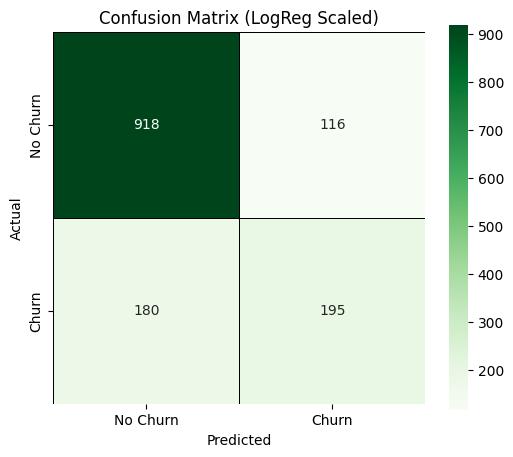

In [ ]:
# Create a confusion matrix to visualize correct and incorrect predictions of the model
cm = confusion_matrix(y_test, y_predsc)
labels = ['No Churn', 'Churn']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, linewidths=0.5, linecolor='black', square=True)
plt.title('Confusion Matrix (LogReg Scaled)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# how many of the actual positive cases were correctly identified
recall = recall_score(y_test, y_predsc, average='weighted')
print(recall)

0.7899219304471257


In [204]:
# precision score: when it predicts the positive result, how often is it correct?

In [ ]:
f1 = f1_score(y_test, y_predsc, average='weighted')
print(f1)

0.783275512108256
